In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/customer_features_ml.csv"
)

df.head()

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days
0,1,141.90,141.90,1,5.0,6.0,12.00,115,115
1,1,27.19,27.19,1,4.0,3.0,8.29,118,118
2,1,86.22,86.22,1,3.0,25.0,17.22,541,541
3,1,43.62,43.62,1,4.0,20.0,17.63,325,325
4,1,196.89,196.89,1,5.0,13.0,16.89,292,292


In [2]:
df.shape

(95419, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95419 entries, 0 to 95418
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   frequency             95419 non-null  int64  
 1   monetary              95419 non-null  float64
 2   avg_order_value       95419 non-null  float64
 3   category_count        95419 non-null  int64  
 4   avg_review_score      95419 non-null  float64
 5   avg_delivery_days     95419 non-null  float64
 6   total_freight_paid    95419 non-null  float64
 7   recency_days          95419 non-null  int64  
 8   customer_tenure_days  95419 non-null  int64  
dtypes: float64(5), int64(4)
memory usage: 6.6 MB


In [4]:
df.describe()

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days
count,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000
mean,1.034018,213.970410,158.531781,1.011004,4.108819,12.056151,24.838063,242.595406,245.278802
std,0.211235,645.760476,218.573056,0.205166,1.324095,9.453265,28.043745,153.153422,153.649699
min,1.000000,9.590000,1.860000,0.000000,1.000000,0.000000,0.000000,0.000000,4.000000
25%,1.000000,63.990000,60.800000,1.000000,4.000000,6.000000,14.100000,118.000000,121.000000
50%,1.000000,113.330000,103.790000,1.000000,5.000000,10.000000,17.700000,223.000000,226.000000
75%,1.000000,203.300000,175.250000,1.000000,5.000000,15.000000,26.655000,352.000000,355.000000
max,16.000000,109312.640000,13664.080000,5.000000,5.000000,209.000000,1897.760000,728.000000,728.000000


In [5]:
df.isnull().sum()


frequency               0
monetary                0
avg_order_value         0
category_count          0
avg_review_score        0
avg_delivery_days       0
total_freight_paid      0
recency_days            0
customer_tenure_days    0
dtype: int64

In [6]:
features = [
    'frequency',
    'monetary',
    'avg_order_value',
    'category_count',
    'avg_review_score',
    'avg_delivery_days',
    'total_freight_paid',
    'recency_days',
    'customer_tenure_days'
]

X = df[features]

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

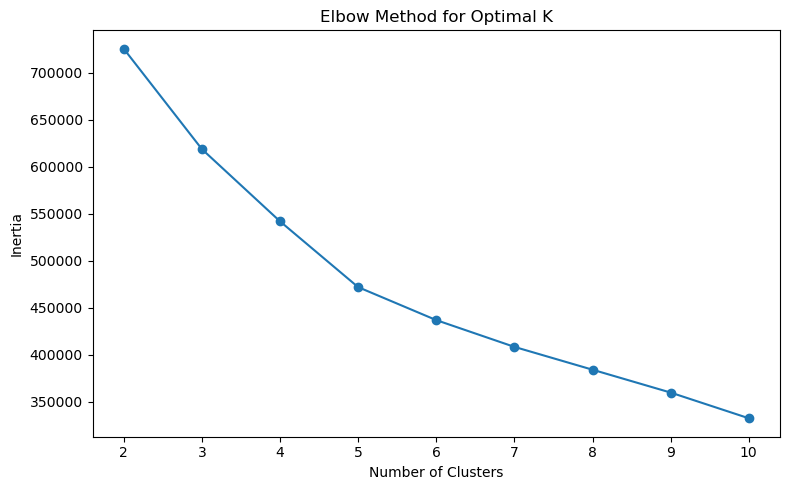

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.title(
    'Elbow Method for Optimal K'
)

plt.xlabel(
    'Number of Clusters'
)

plt.ylabel(
    'Inertia'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/elbow_method.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={k}: {score:.4f}")

K=2: 0.2566
K=3: 0.2742
K=4: 0.2865
K=5: 0.3150
K=6: 0.3179
K=7: 0.2370
K=8: 0.2477
K=9: 0.2487
K=10: 0.2603


In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(
    X_scaled
)

In [12]:
df['cluster'].value_counts()

cluster
2    43122
0    33333
1    14286
4     2886
3     1792
Name: count, dtype: int64

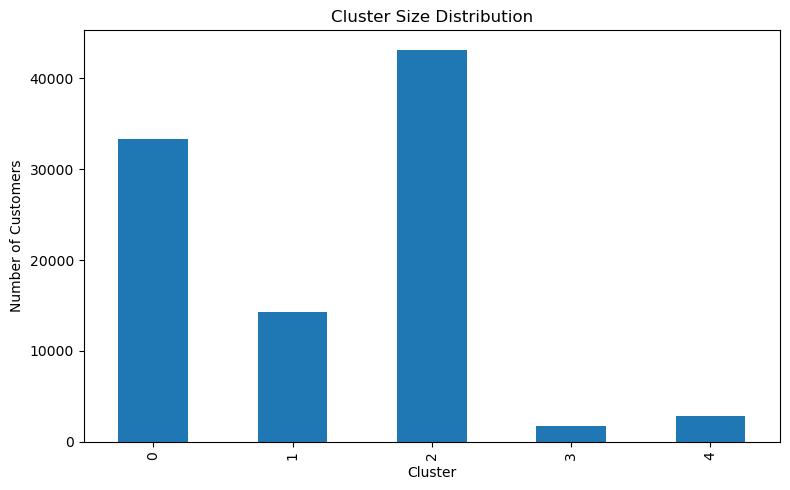

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['cluster'].value_counts()\
    .sort_index()\
    .plot(kind='bar')

plt.title(
    'Cluster Size Distribution'
)

plt.xlabel(
    'Cluster'
)

plt.ylabel(
    'Number of Customers'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/cluster_size_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [14]:
cluster_profile = (
    df
    .groupby('cluster')
    [features]
    .mean()
)

cluster_profile

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days
cluster,,,,,,,,,
0,1.000030,158.354240,135.018105,0.986860,4.488630,11.029655,21.089520,401.475235,401.475565
1,1.000210,211.070950,158.871949,1.001330,1.648677,21.646577,26.698009,222.452681,222.454011
2,1.000046,154.949074,133.953853,0.993089,4.640578,9.587299,21.490085,127.651593,127.652544
3,1.022879,2374.332997,1216.429766,1.016183,3.799431,14.490636,115.602143,242.743862,243.665737
4,2.108455,411.137342,138.787484,1.602218,4.146667,11.815877,52.593188,224.632363,312.755717


In [15]:
cluster_profile.to_csv(
    '../data/cluster_profiles.csv'
)

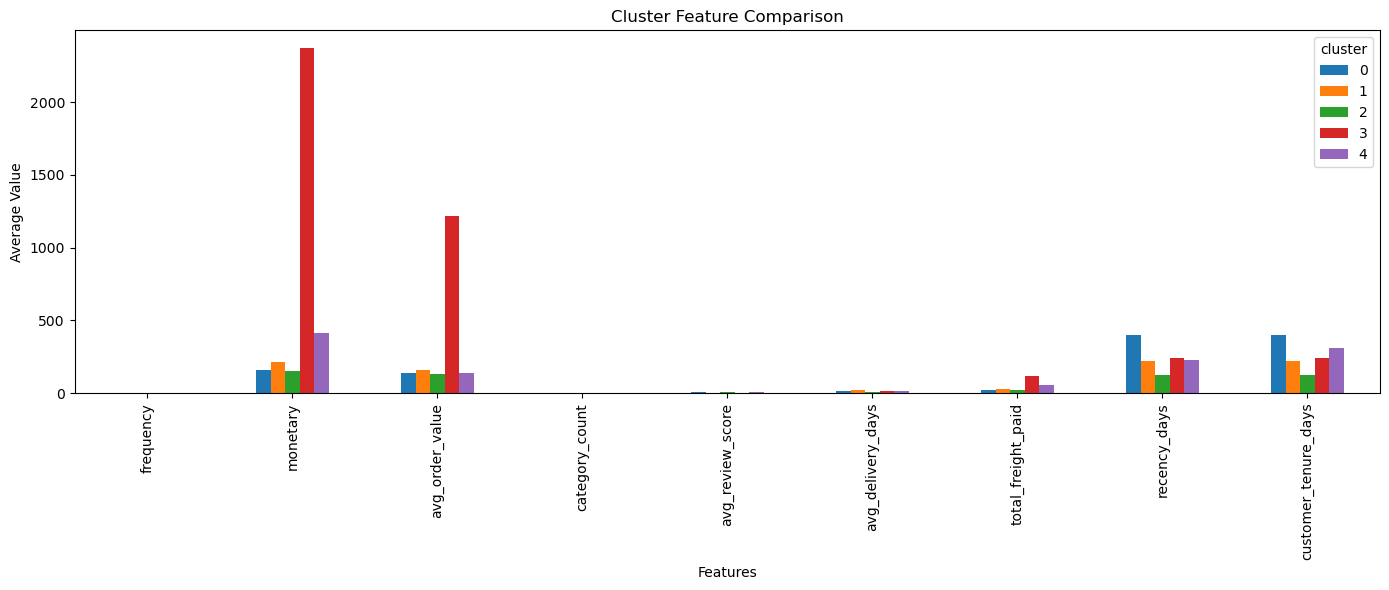

In [16]:
cluster_profile.T.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title(
    'Cluster Feature Comparison'
)

plt.xlabel(
    'Features'
)

plt.ylabel(
    'Average Value'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/cluster_profiles.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [17]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)


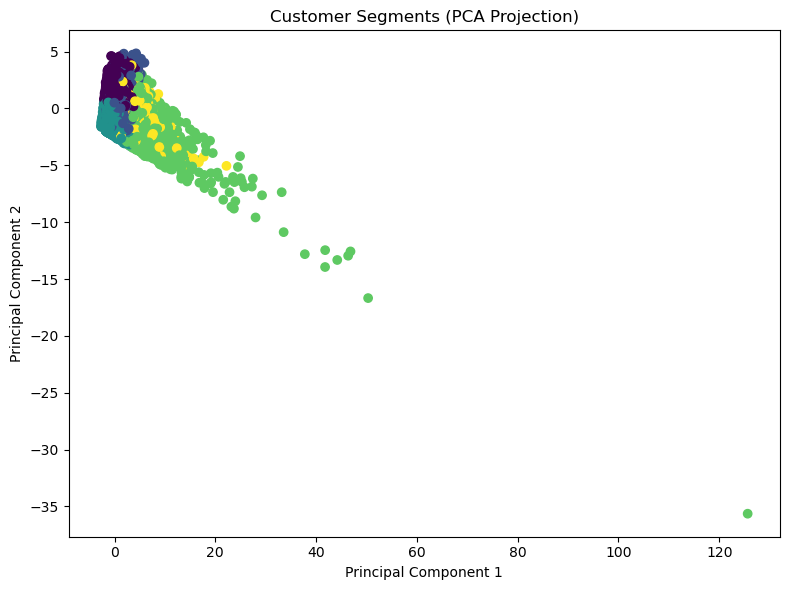

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['cluster']
)

plt.title(
    'Customer Segments (PCA Projection)'
)

plt.xlabel(
    'Principal Component 1'
)

plt.ylabel(
    'Principal Component 2'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/customer_clusters_pca.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [19]:
cluster_profile

,frequency,monetary,avg_order_value,category_count,avg_review_score,avg_delivery_days,total_freight_paid,recency_days,customer_tenure_days
cluster,,,,,,,,,
0,1.000030,158.354240,135.018105,0.986860,4.488630,11.029655,21.089520,401.475235,401.475565
1,1.000210,211.070950,158.871949,1.001330,1.648677,21.646577,26.698009,222.452681,222.454011
2,1.000046,154.949074,133.953853,0.993089,4.640578,9.587299,21.490085,127.651593,127.652544
3,1.022879,2374.332997,1216.429766,1.016183,3.799431,14.490636,115.602143,242.743862,243.665737
4,2.108455,411.137342,138.787484,1.602218,4.146667,11.815877,52.593188,224.632363,312.755717


In [20]:
segment_map = {
    0: 'Inactive Customers',
    1: 'Dissatisfied Customers',
    2: 'Active Customers',
    3: 'VIP Customers',
    4: 'Loyal Customers'
}

df['customer_segment'] = (
    df['cluster']
    .map(segment_map)
)

In [21]:
df.to_csv(
    '../data/customer_segments.csv',
    index=False
)

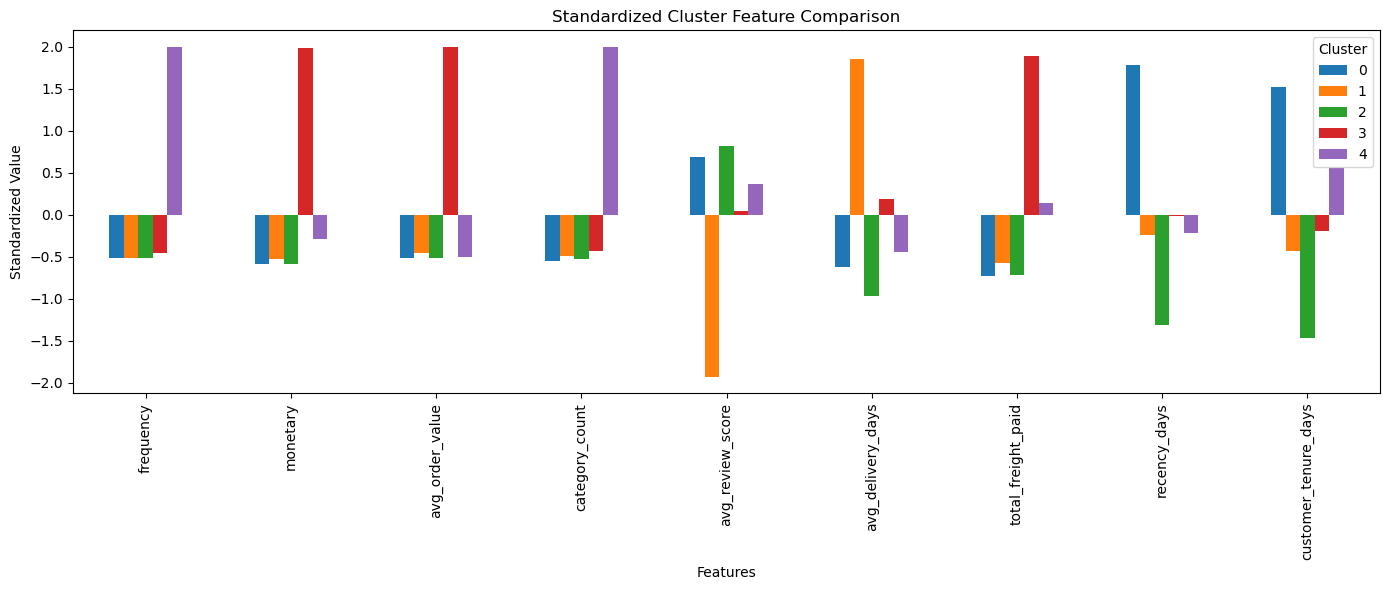

In [22]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Standardize cluster profile values
profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

# Plot
profile_scaled.T.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title(
    'Standardized Cluster Feature Comparison'
)

plt.xlabel(
    'Features'
)

plt.ylabel(
    'Standardized Value'
)

plt.legend(
    title='Cluster'
)

plt.tight_layout()

# Save figure
plt.savefig(
    '../visualizations/standardized_cluster_profiles.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()